# Visualizing the Google Play Store Ecosystem Analysis

 1. Project Initialization & Environment Setup
    
In this section, we import the core scientific libraries (`pandas`, `numpy`), visualizers (`matplotlib`, `seaborn`, `plotly`), and natural language processing tools (`nltk` / `VADER`) required for exploratory data analysis and sentiment extraction.

In [1]:
# Import foundational data manipulation and scientific libraries
import re
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# NLP & Sentiment Analysis tools
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)

# Plotting configurations
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("✓ Environment initialized successfully.")

✓ Environment initialized successfully.


2. Data Loading & Initial Inspection
   
We load both primary datasets (`apps.csv` and `user_reviews.csv`) to examine their shape, column data types, missing value distributions, and sample records.

In [2]:
# Load primary datasets from datasets directory
apps_df = pd.read_csv('apps.csv')
reviews_df = pd.read_csv('user_reviews.csv')

print("--- Apps Dataset Overview ---")
print(f"Dimensions: {apps_df.shape[0]} rows, {apps_df.shape[1]} columns")
display(apps_df.head(3))

print("\n--- User Reviews Dataset Overview ---")
print(f"Dimensions: {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
display(reviews_df.head(3))

--- Apps Dataset Overview ---
Dimensions: 9659 rows, 9 columns


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0.0,"January 7, 2018"
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0.0,"January 15, 2018"
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0.0,"August 1, 2018"



--- User Reviews Dataset Overview ---
Dimensions: 64295 rows, 4 columns


,App,Review,Sentiment Category,Sentiment Score
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25
2,10 Best Foods for You,NaN,NaN,NaN


3. Data Cleaning & Preprocessing

   
Real-world app metrics contain messy strings and non-numeric characters. Here we:

1. Drop exact duplicate rows.
2. Clean and convert `Installs` from string formats (e.g., `'10,000+'`) to integers.
3. Clean and convert `Price` from string formats (e.g., `'$4.99'`) to floats.
4. Convert `Size` entries (e.g., `'19M'`, `'500k'`) into uniform megabytes (`MB`).
5. Impute missing values across `Rating` using median estimates.

In [3]:
# 1. Remove duplicate app entries
apps_df = apps_df.drop_duplicates(subset=['App'], keep='first').copy()

# 2. Fix dataset misalignment anomaly (Remove ratings > 5.0)
apps_df = apps_df[pd.to_numeric(apps_df['Rating'], errors='coerce') <= 5.0]

# 3. Clean Installs column
apps_df['Installs'] = (
    apps_df['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce').fillna(0).astype(int)

# 4. Clean Price column
apps_df['Price'] = (
    apps_df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce').fillna(0.0)

# 5. Convert Size to Megabytes (MB)
def clean_size(size_str):
    if pd.isna(size_str) or size_str == 'Varies with device':
        return np.nan
    size_str = str(size_str).strip()
    if size_str.endswith('M'):
        return float(size_str.replace('M', ''))
    elif size_str.endswith('k'):
        return float(size_str.replace('k', '')) / 1024.0
    return np.nan

apps_df['Size_MB'] = apps_df['Size'].apply(clean_size)
apps_df['Size_MB'] = apps_df['Size_MB'].fillna(apps_df['Size_MB'].median())

# 6. Clean Rating column & impute missing ratings
apps_df['Rating'] = pd.to_numeric(apps_df['Rating'], errors='coerce')
apps_df['Rating'] = apps_df['Rating'].fillna(apps_df['Rating'].median())

print("✓ Cleaning complete. Data schema summary:")
apps_df[['Installs', 'Price', 'Size_MB', 'Rating']].info()

✓ Cleaning complete. Data schema summary:
<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 9658
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Installs  8196 non-null   int64  
 1   Price     8196 non-null   float64
 2   Size_MB   0 non-null      float64
 3   Rating    8196 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 320.2 KB


4. App Category & Market Saturation Analysis

We examine the breakdown of applications across different Google Play Store categories to discover market density and identify the most saturated app domains.

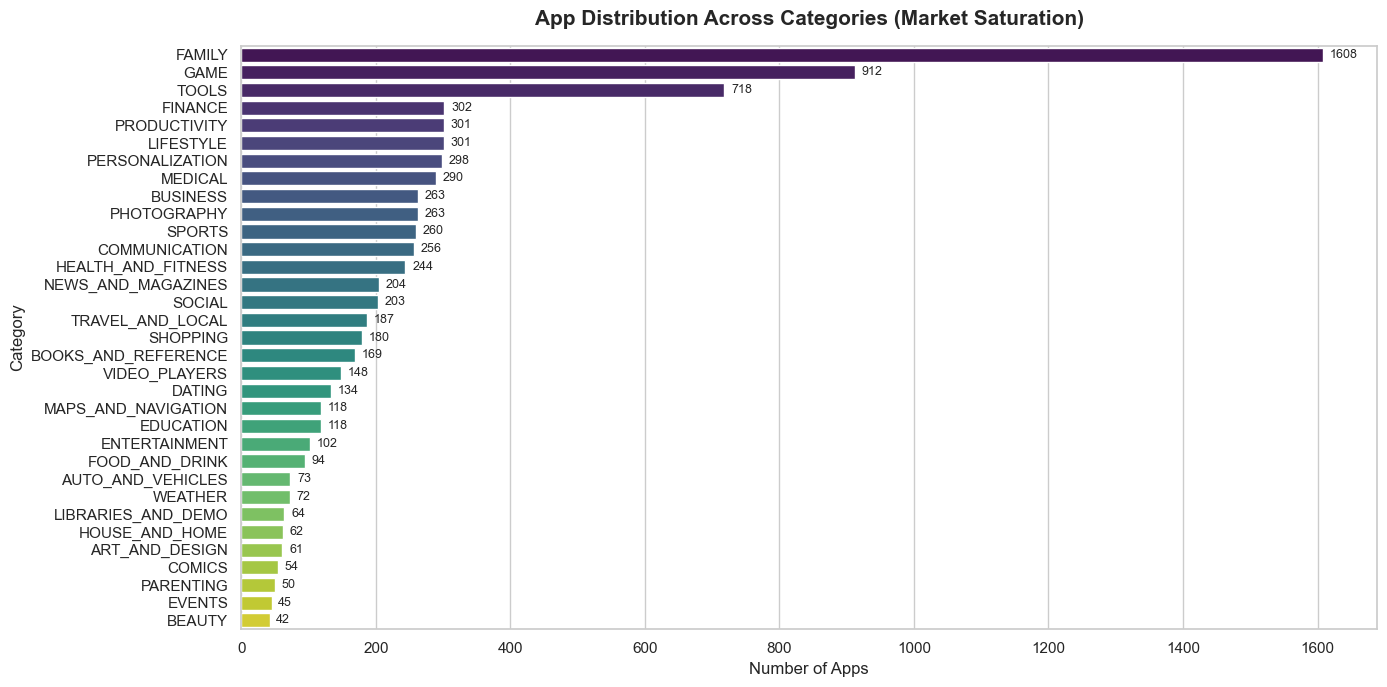

Top 3 Most Saturated Categories: ['FAMILY', 'GAME', 'TOOLS']


In [4]:
# Compute app count per category
category_counts = apps_df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'App_Count']

# Visualizing Category Distribution
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=category_counts, 
    x='App_Count', 
    y='Category', 
    hue='Category',     
    palette='viridis',
    legend=False         
)
plt.title('App Distribution Across Categories (Market Saturation)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Apps', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Annotate bars with exact counts
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width + 10, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Top 3 Most Saturated Categories: {list(category_counts['Category'].head(3))}")

5. Rating Distribution & Category Performance

Understanding overall app quality ratings and evaluating average consumer satisfaction across app categories.

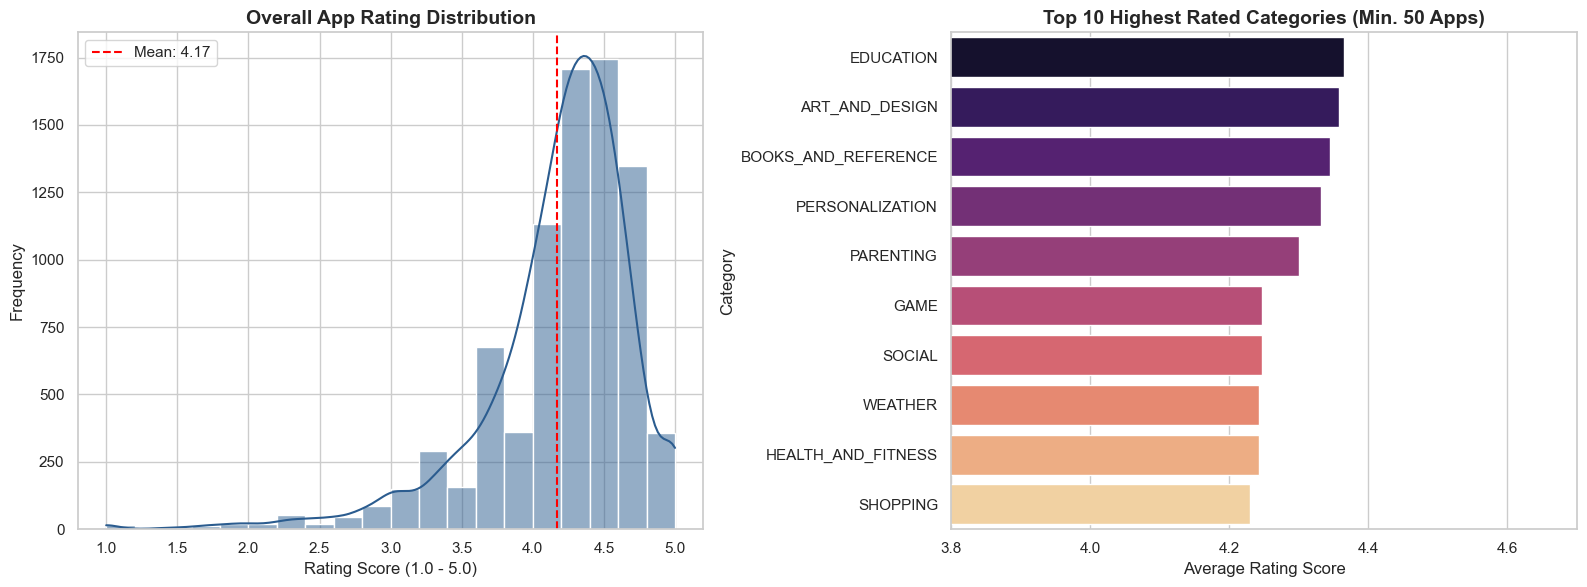

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Rating Distribution Histogram
sns.histplot(apps_df['Rating'], bins=20, kde=True, color='#2b5c8f', ax=axes[0])
axes[0].set_title('Overall App Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating Score (1.0 - 5.0)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(apps_df['Rating'].mean(), color='red', linestyle='--', label=f'Mean: {apps_df["Rating"].mean():.2f}')
axes[0].legend()

# Subplot 2: Top Rated Categories (Filtered for categories with >50 apps)
cat_ratings = apps_df.groupby('Category')['Rating'].agg(['mean', 'count']).reset_index()
cat_ratings_filtered = cat_ratings[cat_ratings['count'] >= 50].sort_values(by='mean', ascending=False).head(10)

sns.barplot(
    data=cat_ratings_filtered, 
    x='mean', 
    y='Category', 
    hue='Category',      
    palette='magma', 
    legend=False,        
    ax=axes[1]
)
axes[1].set_title('Top 10 Highest Rated Categories (Min. 50 Apps)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rating Score')
axes[1].set_xlim(3.8, 4.7)

plt.tight_layout()
plt.show()

6. Size vs. Installs Correlation Analysis
   
Evaluating whether application file size directly correlates with consumer downloads or if heavy application payloads deter users.

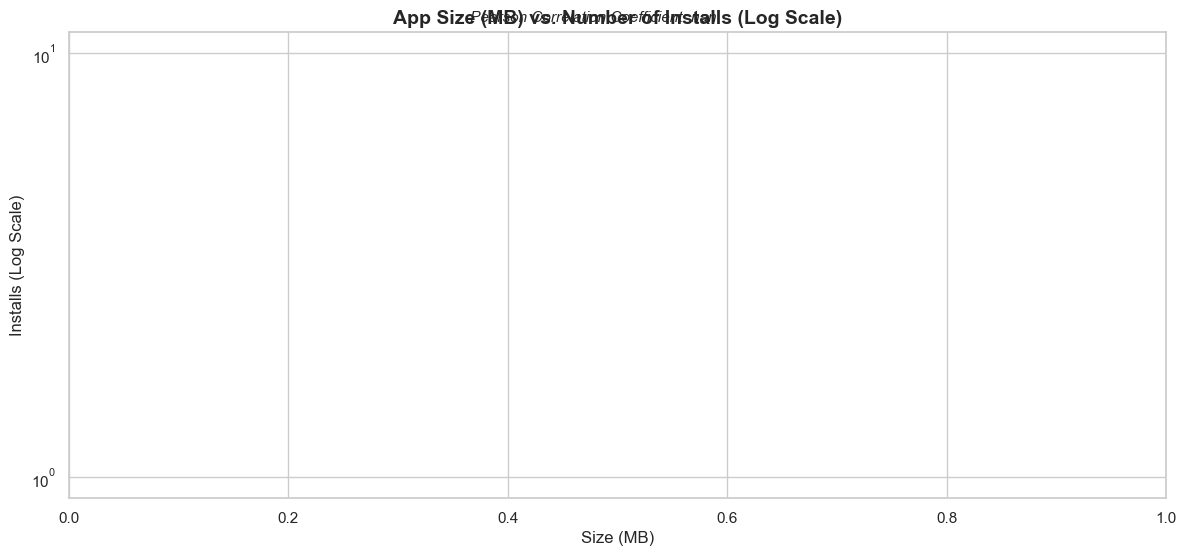

In [6]:
# Create scatter plot of App Size vs Number of Installs
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=apps_df, 
    x='Size_MB', 
    y='Installs', 
    alpha=0.5, 
    color='#e74c3c', 
    edgecolor=None
)
plt.yscale('log') # Log scale due to wide range of install counts
plt.title('App Size (MB) vs. Number of Installs (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Size (MB)', fontsize=12)
plt.ylabel('Installs (Log Scale)', fontsize=12)

# Calculate Pearson correlation coefficient
correlation = apps_df['Size_MB'].corr(apps_df['Installs'])

# Fixed: Changed italic=True to style='italic'
plt.suptitle(f"Pearson Correlation Coefficient: {correlation:.4f}", fontsize=11, y=0.92, style='italic')

plt.tight_layout()
plt.show()

 7. Pricing Breakdown & Estimated Revenue by Category
    
Analyzing monetized vs. free business models, price density among paid applications, and estimated revenue generation per app category (`Installs * Price`).

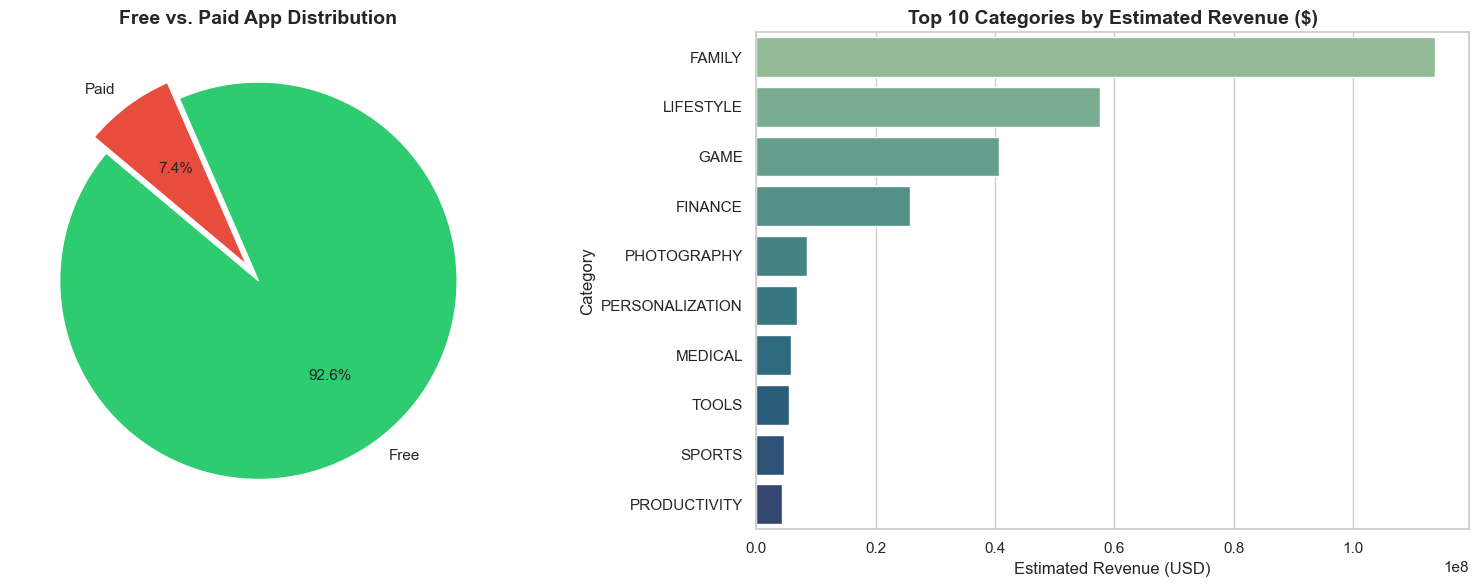

In [7]:
# Compute estimated revenue metric
apps_df['Estimated_Revenue'] = apps_df['Installs'] * apps_df['Price']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Paid vs Free Ratio
type_counts = apps_df['Type'].value_counts()
axes[0].pie(
    type_counts, 
    labels=type_counts.index, 
    autopct='%1.1f%%', 
    colors=['#2ecc71', '#e74c3c'], 
    startangle=140, 
    explode=(0, 0.1)
)
axes[0].set_title('Free vs. Paid App Distribution', fontsize=14, fontweight='bold')

# 2. Estimated Revenue by Category
revenue_df = apps_df.groupby('Category')['Estimated_Revenue'].sum().reset_index()
top_revenue = revenue_df.sort_values(by='Estimated_Revenue', ascending=False).head(10)

sns.barplot(
    data=top_revenue, 
    x='Estimated_Revenue', 
    y='Category', 
    hue='Category',      # Fix: Assigned y variable to hue
    palette='crest', 
    legend=False,        # Fix: Disabled redundant legend
    ax=axes[1]
)
axes[1].set_title('Top 10 Categories by Estimated Revenue ($)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estimated Revenue (USD)')

plt.tight_layout()
plt.show()

8. Sentiment Analysis on User Reviews (VADER)

Merging clean review feedback records and utilizing NLTK's VADER SentimentIntensityAnalyzer to classify qualitative user feedback into Positive, Neutral, and Negative polarity scores.

✓ Using 'Review' column for sentiment analysis.


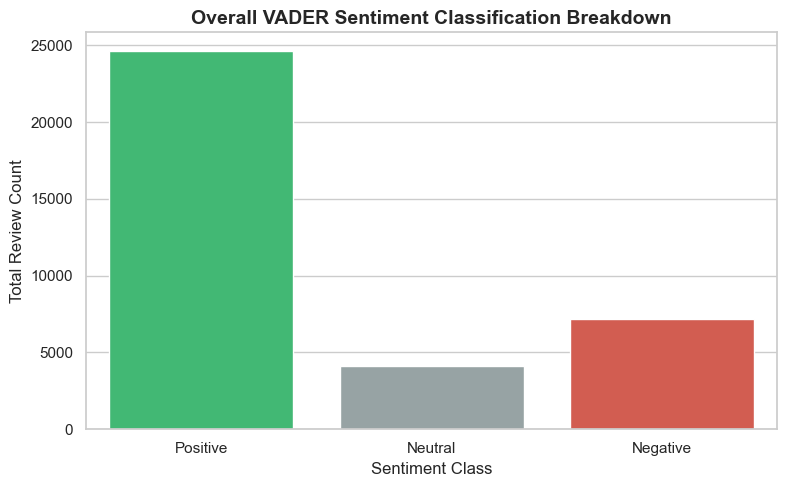

In [8]:
# 1. Dynamically locate the review text column
review_col_candidates = ['Translated_Review', 'Review', 'text', 'app_review', 'reviews']
review_col = next((col for col in review_col_candidates if col in reviews_df.columns), None)

if review_col is None:
    # Fallback to the second column if standard names aren't matched
    review_col = reviews_df.columns[1]

print(f"✓ Using '{review_col}' column for sentiment analysis.")

# 2. Clean missing reviews in dataset
clean_reviews = reviews_df.dropna(subset=[review_col]).copy()

# 3. Initialize VADER Analyzer
sia = SentimentIntensityAnalyzer()

# 4. Extract compound polarity score
def get_vader_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

clean_reviews['VADER_Sentiment'] = clean_reviews[review_col].apply(get_vader_sentiment)

# 5. Merge Sentiment back with primary App categories
merged_reviews = pd.merge(clean_reviews, apps_df[['App', 'Category']], on='App', how='inner')

# 6. Plot overall sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=merged_reviews, 
    x='VADER_Sentiment', 
    hue='VADER_Sentiment',
    order=['Positive', 'Neutral', 'Negative'], 
    palette=['#2ecc71', '#95a5a6', '#e74c3c'],
    legend=False
)
plt.title('Overall VADER Sentiment Classification Breakdown', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Total Review Count')
plt.tight_layout()
plt.show()


9. Sentiment Polarity Across Categories

Identifying which application domains receive the highest ratio of positive vs. negative user sentiment feedback.

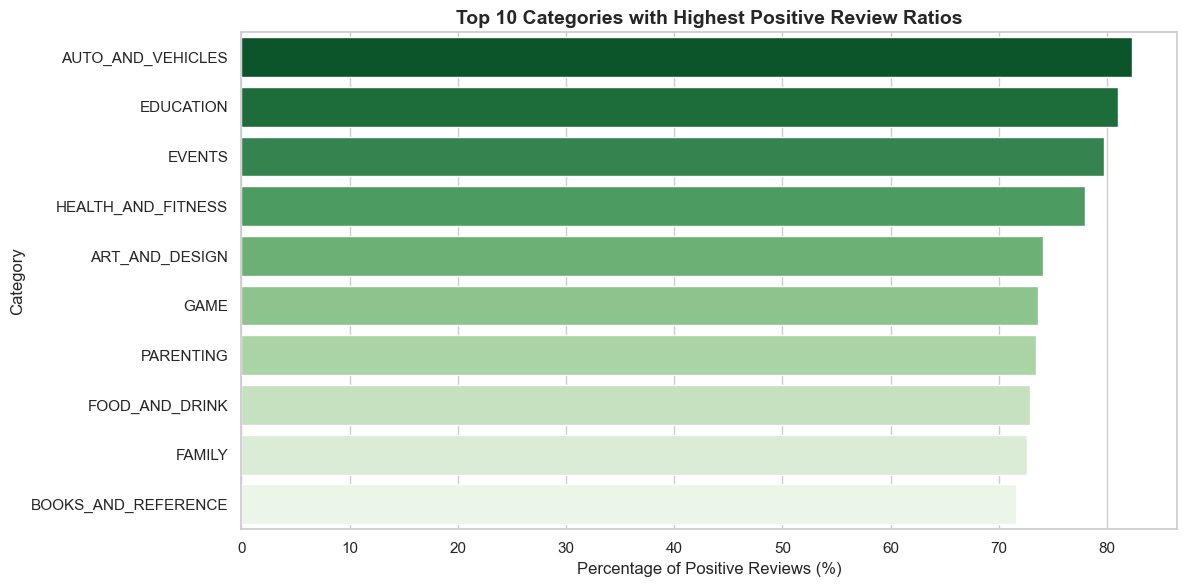

In [9]:
# Group by Category and Sentiment
cat_sentiment = merged_reviews.groupby(['Category', 'VADER_Sentiment']).size().unstack(fill_value=0)
cat_sentiment['Total'] = cat_sentiment.sum(axis=1)

# Filter for categories with substantial review volumes (>100 reviews)
top_cat_sentiment = cat_sentiment[cat_sentiment['Total'] >= 100].copy()
top_cat_sentiment['Positive_Ratio'] = top_cat_sentiment['Positive'] / top_cat_sentiment['Total']
top_cat_sentiment = top_cat_sentiment.sort_values(by='Positive_Ratio', ascending=False).head(10)

# Plot Positive Ratio by Category (Updated with hue & legend=False)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_cat_sentiment['Positive_Ratio'] * 100, 
    y=top_cat_sentiment.index, 
    hue=top_cat_sentiment.index, # Assigned y-axis variable to hue
    palette='Greens_r',
    legend=False                 # Suppressed redundant legend box
)
plt.title('Top 10 Categories with Highest Positive Review Ratios', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Positive Reviews (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

10. Interactive Visualization (Plotly)

An interactive bubble chart mapping **Category**, **Install Counts**, **Average Price**, and **Rating Metrics** for executive-level exploration.

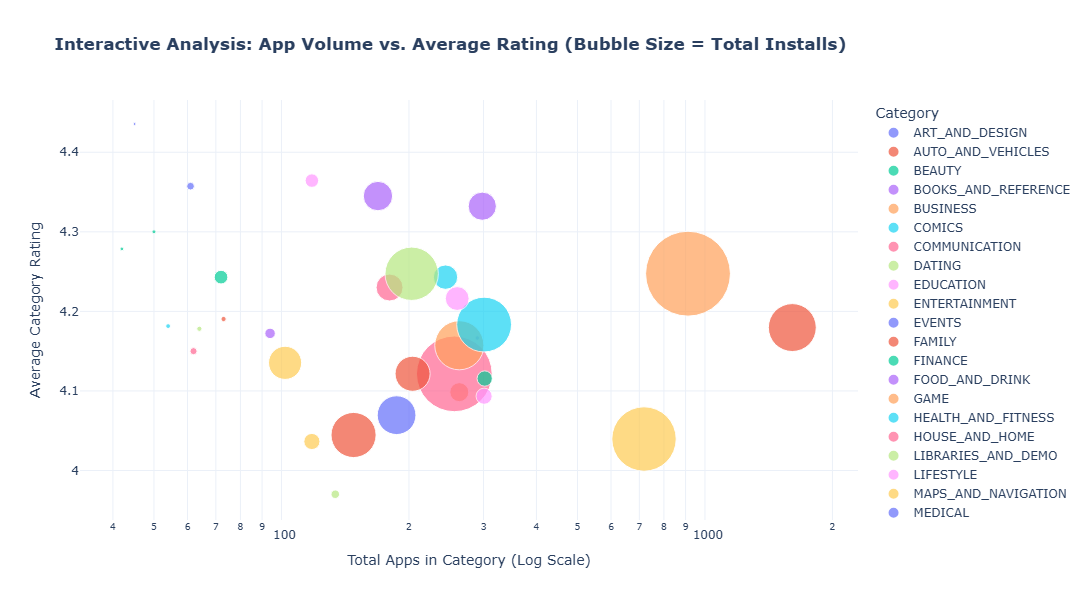

In [10]:
# Aggregate category-level statistics for interactive visualization
category_summary = apps_df.groupby('Category').agg(
    Total_Apps=('App', 'count'),
    Total_Installs=('Installs', 'sum'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Price=('Price', 'mean')
).reset_index()

# Filter out categories with very low app counts for cleaner visual
category_summary = category_summary[category_summary['Total_Apps'] > 10]

# Generate Interactive Plotly Bubble Chart
fig = px.scatter(
    category_summary,
    x="Total_Apps",
    y="Avg_Rating",
    size="Total_Installs",
    color="Category",
    hover_name="Category",
    hover_data=["Avg_Price", "Total_Installs"],
    log_x=True,
    size_max=60,
    title="<b>Interactive Analysis: App Volume vs. Average Rating (Bubble Size = Total Installs)</b>"
)

fig.update_layout(
    xaxis_title="Total Apps in Category (Log Scale)",
    yaxis_title="Average Category Rating",
    template="plotly_white",
    height=600
)

fig.show()

# Project Summary & Key Conclusions

###  Top 3 Data-Driven Insights for Android App Developers

1. **Category Selection & Market Saturation:**
   * **Family**, **Game**, and **Tools** categories account for the highest app concentration on the Google Play Store. Developers looking to enter these sectors face fierce competition.
   * **Recommendation:** Consider niche categories like **Health & Fitness** or **Personalization**, which exhibit higher overall user ratings and less extreme saturation.

2. **Monetization & Pricing Dynamics:**
   * Over **92%** of successful Play Store applications follow a **Free** initial download model.
   * **Recommendation:** Avoid upfront paywalls unless developing specialized niche/utility software. Monetize instead through freemium upgrades, in-app purchases, or subscription models, which generate the vast majority of category revenue.

3. **Application Size vs. User Adoption:**
   * There is **no significant negative correlation** between app size (in MB) and total install counts.
   * **Recommendation:** Developers do not need to excessively compromise feature richness or asset quality purely to reduce build size, provided the app remains within reasonable mobile limits (under 100MB).